# Figure 1 notebook for DASIT in 293Ts w/ Puro selection (TagBFP)
Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Infected at 6-well scale \
Reseed at 20k/well into antibiotic conditions \
Media change every other day \
Flow on 6 dpi \



Reps:
- 2026.06.03: 3 reps


In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.patches import Patch

In [2]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.03_exp47': ['Plate1', 'Plate2', 'Plate3', 'Plate4']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_1_selection'
cache_path = rd.rootdir/'output'/'Figure_1_selection'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A', 'TagBFP-A', 'TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove negative values from dataframe
    for c in channel_list: data = data[data[c] > 0]

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
data['conds'] = data['reporter'] +'.'+ data['Puro'] 
display(data)

,reporter,Puro,Puro#,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,conds
0,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,239937,176223,114.0,89.0,20199.0,17256.0,51.0,84.0,pKG05002.10x
2,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,360555,177861,66680.0,48986.0,46504.0,37146.0,570.0,381.0,pKG05002.10x
3,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,303230,170924,67.0,50.0,10007.0,8310.0,255.0,141.0,pKG05002.10x
4,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,288188,248845,78.0,63.0,17562.0,14627.0,155.0,151.0,pKG05002.10x
6,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,285615,233808,51146.0,36900.0,3291.0,2688.0,417.0,387.0,pKG05002.10x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23010621,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,445454,243535,1774.0,436.0,15.0,92.0,224.0,122.0,Untransfected.0x
23010623,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,442954,260523,65.0,143.0,73.0,105.0,265.0,113.0,Untransfected.0x
23010624,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,486336,189201,76.0,85.0,91.0,80.0,275.0,141.0,Untransfected.0x
23010625,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,390673,139733,97.0,88.0,105.0,74.0,99.0,96.0,Untransfected.0x


In [5]:
untransfected = data[data['reporter'] == 'Untransfected']

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

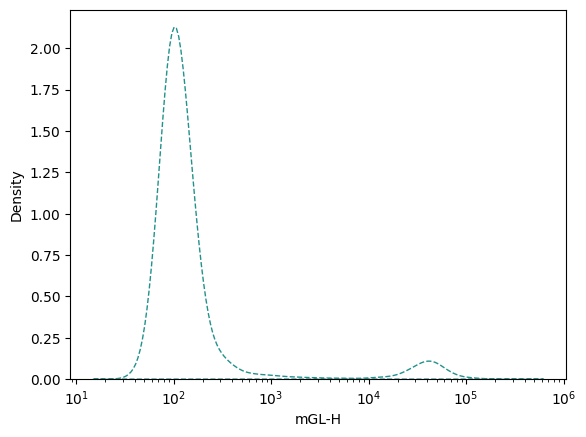

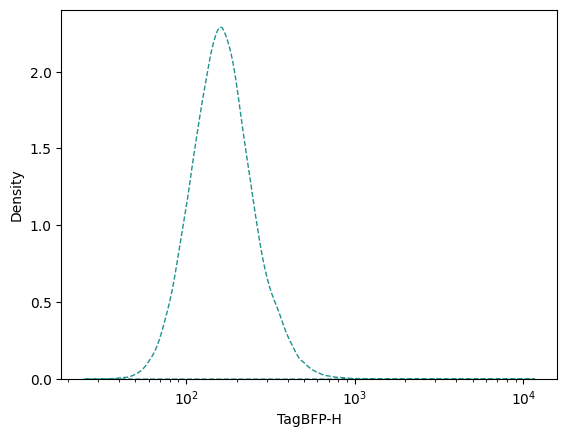

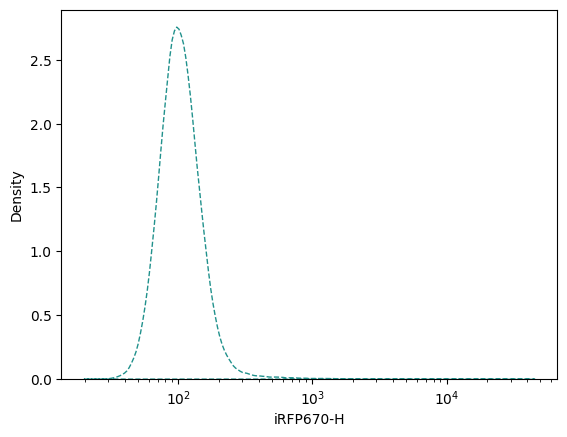

In [7]:
parameters = np.array(['mGL-H', 'TagBFP-H', 'iRFP670-H'])
for param in parameters:
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [12]:
iRFP670_H_thresh = 2.5e2
eGFP_gate = 3000
TagBFP_gate = 2000

In [10]:
data = data[(data['reporter'] != 'pKG04437.Controls') & (data['reporter'] != 'pKG05003.Controls')]

**Gate for infected cells**

In [11]:
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'reporter', 'conds', 'Date', 'Puro']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

**Gate for EGFP+ cells**

In [14]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['mGL-H'] > eGFP_gate), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'reporter', 'conds', 'Date', 'Puro']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

**Count total cells in each 96-well**

In [15]:
# Convert to dataframe
data_eGFP_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_eGFP_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_eGFP_count_reps = data_eGFP_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

**Conditions for plotting**

In [18]:
Puro_conds = ['0x', '2.5x', '5x','10x','20x']

## Bar plots

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_ol

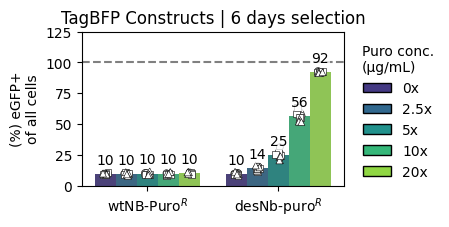

In [22]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

antibiotic_map = {
    'pKG04437':'Puro',
    'pKG04440':'Puro',
    'pKG05003':'Puro',
    'pKG05002':'Puro'
}

label_map = {
    'pKG04437':'wtNB-Puro$^R$',
    'pKG04440':'desNb-puro$^R$',
    'pKG05003':'wtNb-puro$^R$',
    'pKG05002':'desNb-puro$^R$'
}

df_curr = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.reporter == 'pKG04437') | (data_eGFP_percent_reps.reporter == 'pKG04440')]

hue = 'Puro'

# enforce ordering based on Puro_conds
hue_order = [p for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, hue=hue,hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.Date.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.Date == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 125))

# Title
ax.set_title('TagBFP Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'tagBFP_DASIT_puro.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


## eGFP+ cell counts

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_ol

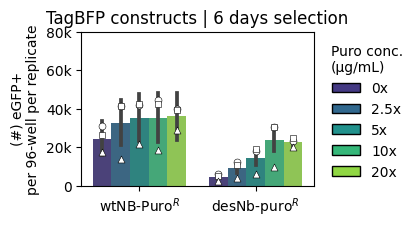

In [21]:
# General plotting params
x = 'reporter'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.reporter == 'pKG04437') | (data_eGFP_count_reps.reporter == 'pKG04440') & (data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

hue = 'Puro'

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, hue=hue, hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )


# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

 # Formatting
ax.yaxis.set_label_text('(#) eGFP+\nper 96-well per replicate')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 80e3))
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
#     title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'TagBFP constructs | 6 days selection')
ax.set_xlabel('')

plottitle = 'tagBFP_DASIT_puro_eGFP_cell_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Total cells

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_ol

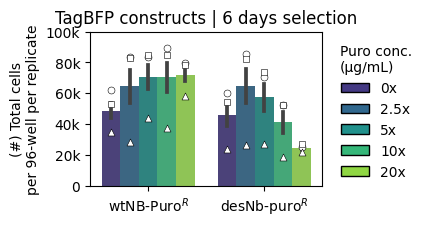

In [ ]:
# General plotting params
x = 'reporter'
y = 'total_cells'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.reporter == 'pKG04437') | (data_eGFP_count_reps.reporter == 'pKG04440')]

hue = 'Puro'

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y,hue=hue, hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )


# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

 # Formatting
ax.yaxis.set_label_text('(#) Transduced cells\nper 96-well per replicate')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 100e3))
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
#     title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'TagBFP constructs | 6 days selection')
ax.set_xlabel('')

plottitle = 'tagBFP_DASIT_puro_total_cell_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')
